# Project 1 : Getting Started with Python and algorithms
You must complete each question and answer all parts. Read carefully. Some questions are meant to be exploratory and open-ended. Your submissions must be organized. If you are not using a jupyter notebook, you will have to include all required figures and reference the figures in your answers (e.g., "...see Figure 1 in attached file" with Figure 1 labeled in a separately attached file).

I expect a write up (e.g., jupyter notebook) that demonstrates both _how_ and _why_ everything was done. All figures should be clearly labeled with axes labels, titles, and legends. Any code must be included. Any suspection of AI-generating or external code-writing tools will result in a meeting with me.

In [1]:
# setup
import matplotlib.pyplot as plt
import numpy as np

## S1: Difficulty with computation

### Question 1 (polynomial evaluation)
If we place algorithms near the core of Data Science, we had better get some practice at analyzing algorithms. This includes determining _why_ and algorithm _should_ work and testing if it _actually_ works.

Consider an $N^{\text{th}}$ degree polynomial expressed using [Sigma Notation](https://en.wikipedia.org/wiki/Summation)
\begin{equation}
p(x) = \sum_{k=0}^{N} a_k x^k = a_0 + a_1x + a_2x^2+a_3x^3 + \dots + a_Nx^N
\end{equation}

For example, if $p(x) = 4x^2 + 2x - 1$, then $N=2$ and the coefficients are given by $a_0 = -1$ (constant term), $a_1 = 2$ (linear term), and $a_2 = 4$ (quadratic term).

Polynomials are everywhere in all levels of math. So, we had better have efficient ways of evaluating them. **Horner's rule** for polynomial evaluation outline with the following procedure:
\begin{align*}
    & p = a_N \\
    & \text{for } k = N-1 \text{ down to } 0 \\
    & \quad\quad  p = x \, * \, p + a_k \\
    & \\
    & \text{return } p
\end{align*}

What is the deal with such an bizarre looking algorithm? For starters, a computer can only do what you tell it to do. So, when we consider any mathematical operation, it is helpful to thin of algorithms in terms of their most elementary operations (addition, subtraction, multiplication, and division). Notice that Horner's method evaluates a polynomial without ever raising a number to a power (e.g., `**` in python). Neat!

**PROMPT** Show mathematically that Horner's rule is a valid algorithm for polynomial evaluation.

**ANSWER**
Well, looking at the first few cases, trying to determine a pattern
for $N = 1$:
Then, $p = a_1 * x + a_0$
for $N  = 2$:
Then, $p = a_2 * x^2 + a_1 * x + a_0$
and for general $N$ (positive integer):
$p = a_N * x^N + a_(N-1) * x^(N-1) + ... + a_1 * x + a_0$
where the $N$ index indicating the degree of the polynomial term
ie. $a_0$ is a constant term, $a_1$ is the coefficient of $x^1$, $a_2$ is the coefficient of $x^2$, etc.

### Question 2 (code for Horner's rule)
The following code evaluates a polynomial using Horner's rule at $x$-values given in `x` with coefficients given in `coefficients`, where `coefficients[0]` corresponds to the constant term in the polynomial. In the following code, we make use of the `numpy` Python library, and so we `import` the library.

In [2]:
import numpy as np

def horners_rule(x, coefficients):
    N = len(coefficients)
    y_out = coefficients[-1] * np.ones( np.shape(x) )
    
    for k in np.flip( range(N-1) ):
        y_out = x * y_out + coefficients[k]
    
    return y_out

**PROMPT** Create a graph of $f(x)=x^2-4$ using Python's built-in capabilities (i.e., without using Horner's method). On the same axes, create a scatter plot (try using `plt.scatter()`) of $f(x)$ instead evaluated using the above Horner's method (so, you are free to call `horners_rule()`). Use 100 points in your scatter plot. In both cases, restrict your input between $x=-3$ and $x=3$.

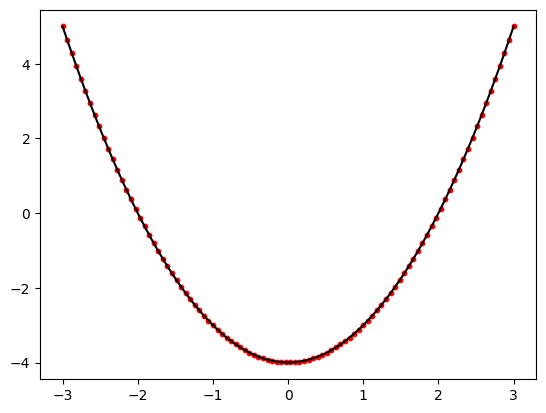

In [3]:
# **ANSWER**
x = np.linspace(-3, 3, 100)
f = lambda x: x**2 - 4

coefficients = [ -4, 0, 1 ] # from a_0 to a_{N-1}
plt.plot(x, f(x), label='f(x)', color='black')
plt.scatter(x, horners_rule(x, coefficients), color='red', label="Horner's method", s=10)
plt.show()

** ANSWER **
Horner's rule seems to produce a decent fitting set of points for the function f.

### Question 3 (Horner's rule, sad-face)
Consider the function $g(x) = (x-2)^9$. If this function is expanded out, the polynomial is given by
\begin{equation}\label{E:expandedHorner}
    g(x) = x^9 - 18x^8 + 144x^7 - 672 x^6 + 2016x^5 -4032 x^4 + 5376x^3 - 4608x^2 + 2304x - 512
\end{equation}

**PROMPT** Plot $g(x) = (x-2)^9$ using Python's built in capabilities. On the same axes, create a scatter plot of the function evaluated at 1000 points using Horner's method and the coefficients in \eqref{E:expandedHorner}. Restrict your plot to the interval $[1.92, 2.08]$. As an argument in your scatter, use `s=1`. This sets the size of your scatter to 1. Comment on what you observe

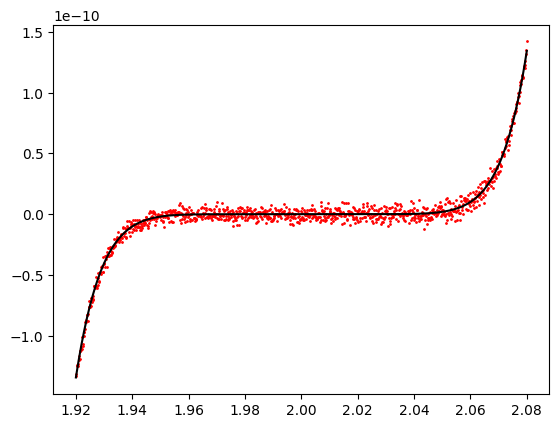

In [4]:
g = lambda x: (x - 2)**9
x = np.linspace(1.92, 2.08, 1000)
y = g(x)
plt.plot(x, y, label='g(x)', color='black')
coefficents = [-512, 2304, -4608, 5376, -4032, 2016, -672, 144, -18, 1] # from a_0 to a_{N-1} ASC order
plt.scatter(x, horners_rule(x, coefficents), color='red', label="Horner's method", s=1)
plt.show()

** ANSWER ** Observation: The black line (the function itself) is relatively matched up with the scattered points generated by Horner's method. In this interval, this appears to be a relatively well fit line, but anything further would require some actual error checking

## S2: Bisection and Horner's method

### Question 1 (writing code for bisection)
Write a function called `my_bisection()` that estimates a root of $f(x)$ in an interval $[a,b]$.
Your function should take an argument `tol` and terminate when the squeezed interval is within this tolerance.
For checking purposes, your function should return both the final interval and its midpoint as an estimated root.
Note that this differs from the algorithm we discussed in class in which we only returned the final midpoints as the estimated root.
Your function should print out the number of bisection iterates performed. See below for an example of printing out variable values using the Python `print` command.

In [10]:
dummy_root   = 3.14159
dummy_iterates = 55

print('After %d iterates, the estimated root is %0.4f' %(dummy_iterates, dummy_root))
# The % tells Python where to place the numeric value
# %d formats as an integer
# %0.4 formats as a floating point number with 4 decimals displayed

After 55 iterates, the estimated root is 3.1416


Final iteration depth: 11
Final interval: [1.5205078125, 1.521484375], Estimated root: 1.52099609375


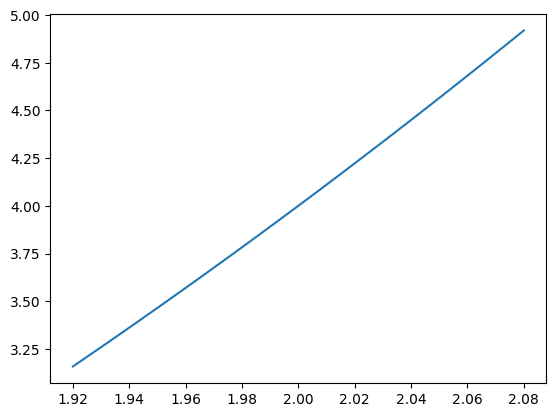

Compare: Scipy's bisect method found root: 1.5205078125


In [7]:

def my_bisection(f, a, b, tol=10e-4):
    """ A recursive implementation of the bisection method. """

    # increase static call counter
    my_bisection.calls += 1

    if f(a) * f(b) >= 0: # same sign
        return None, None

    m = (a + b) / 2.0 # ensure float division

    # check midpoint
    if abs(b-a) <= tol:
        # found root
        return ([a,b], m)
    elif f(a) * f(m) < 0: # sign check
        # in [a, m] (left side of interval)
        b = m
    else: # must be other side of interval
        # in [b, m] (right side)
        a = m
    
    # recursively bisect the new subinterval
    return my_bisection(f, a, b, tol)


f = lambda x: x**3 - x - 2
a = 1
b = 2
tol = 1e-3

my_bisection.calls = 0 # static variable to count calls
interval, root = my_bisection(f, a, b, tol)
# assuming interval and root are not None
print(f"Final iteration depth: {my_bisection.calls}")

print(f"Final interval: {interval}, Estimated root: {root}")

# debug and playing around
plt.plot(x,f(x))
plt.show()

from scipy import optimize
root = optimize.bisect(f, a, b, xtol=tol) # comparing to scipy's built-in bisection method
print(f"Compare: Scipy's bisect method found root: {root}")

### Question 2 (Bisection method two ways)
**PROMPT** Estimate the root of $g(x) = (x-2)^9$ using `my_bisection()`, using Python's built in commands to define $g(x)$.
You are free to set a tolerance to your choose, but you must begin with $a = 1.92$, and $b=2.07$ for the endpoints of your initial interval $[a,b]$.
Plot $g(x)$ using built-in methods. 
Plot the bounding interval as a **blue horizontal** line on the $x$-axis.
Does your interval appear to contain the root?

Final iteration depth: 5
Final interval: [1.9949999999999999, 2.004375], Estimated root: 1.9996874999999998


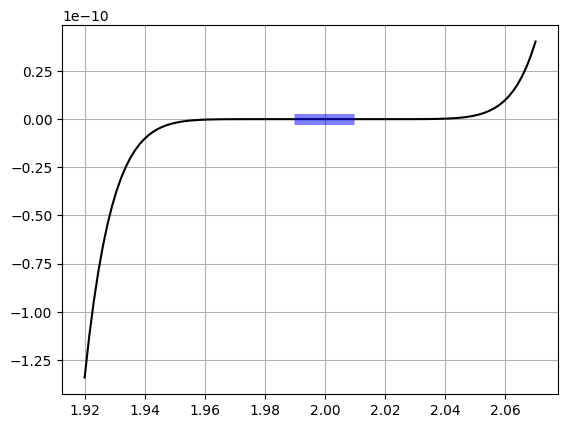

Compare: Scipy's bisect method found root: 2.004375


In [8]:
g = lambda x: (x - 2)**9
a = 1.92
b = 2.07
tol = 1e-2

my_bisection.calls = 0 # reset static variable to count calls
interval, root = my_bisection(g, a, b, tol)
print(f"Final iteration depth: {my_bisection.calls}")

print(f"Final interval: {interval}, Estimated root: {root}")

x = np.linspace(a, b, 100)
fig, ax = plt.subplots()
plt.plot(x, g(x), label='g(x)', color='black')


#plt.fill_between(x, interval[0], interval[1], color='blue', alpha=0.2, label='Interval')
#plt.axhspan(interval[0], interval[1], color="blue", alpha=0.5)


ax.hlines(y=0, xmin=root-tol, xmax=root+tol, linewidth=8, color='b', alpha=0.5)

ax.grid()
plt.show()

from scipy import optimize
root = optimize.bisect(g, a, b, xtol=tol) # comparing to scipy's built-in bisection method
print(f"Compare: Scipy's bisect method found root: {root}")

**PROMPT**
Estimate the root of $g(x) = (x-2)^9$ using `my_bisection()`, using Horner's method to define $g(x)$.
You are free to set a tolerance to your choose, but you must begin with $a = 1.92$, and $b=2.07$ for the endpoints of your initial interval $[a,b]$.
Plot $g(x)$ using built in methods. Plot the bounding interval as a **red horizontal line** on the $x$-axis.
Comment on your result.
Is your error within the theoretical bound?

Final iteration depth: 5
Final interval: [2.004375, 2.01375], Estimated root: 2.0090624999999998


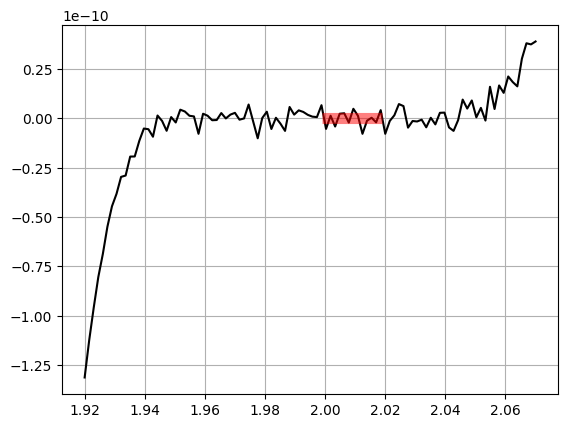

In [10]:
coefficients = [-512, 2304, -4608, 5376, -4032, 2016, -672, 144, -18, 1] # from a_0 to a_{N-1} ASC order
g_horner = lambda x: horners_rule(x, coefficients)
a = 1.92
b = 2.07
tol = 1e-2

my_bisection.calls = 0 # reset static variable to count calls
interval, root = my_bisection(g_horner, a, b, tol)
print(f"Final iteration depth: {my_bisection.calls}")

print(f"Final interval: {interval}, Estimated root: {root}")

x = np.linspace(a,  b, 100)
fig, ax = plt.subplots()
plt.plot(x, g_horner(x), label='g_horner(x)', color='black')


ax.hlines(y=0, xmin=root-tol, xmax=root+tol, linewidth=8, color='r', alpha=0.5)


ax.grid()
plt.show()

### Question 3 (What happened)
Use your plots and understanding of the bisection method to explain what went wrong when using Horner's method to evaluate the polynomial.

** ANSWER **
Well, taking a look at the code and the text output, we can see that the bisection method has to recurse several levels into the interval, and on the 5th call, a midpoint ($x=\frac{b-a}{2}$) was found that satisfied our tolerance ($|b-a| <= tol$). That is all great and dandy, but after taking a look at the function's shape once plotted, we can see that in the interval (defined by our estimated root +/- our tolerance = our solution window) contains not just one, but several zeroes. Upon a quick glance at the plot, around x=2, there are numerous roots of the function. This kind of error (finding one out of many solutions in an interval) is common with the bisection method, Newton's Method and other similar root finding algorithms. The bisection method guarantees that given a function $f(x)$ within $[a,b]$ with $f(a)*f(b) < 0$ and that $f(x)$ is continuous and defined on the interval (essential conditions), it will produce ONE root in the interval. In this case, it worked /as intended/, however, with more careful selection of an interval and tolerance, or perhaps a different root finding method, better results may be obtained.